# Attention vs. functional connectivity (FC) -- 25-subject correlation

For each subject already processed by `run_model.py` (see `outputs/attention_matrices/`),
compare the last-layer region x region **attention** matrix against that subject's own
**functional connectivity (FC)**: the Pearson correlation matrix of the raw BOLD region
time series.

Design choices, stated explicitly:

- **Attention input**: the saved `<sub_id>_attention.npy` files, reused as-is rather than
  re-running the model. `run_model.py` builds each one as
  `attn_reshaped.mean(dim=(1, 3))` on the `[num_regions, num_patches, num_regions, num_patches]`
  reshape of the last-layer attention (`num_patches=10` for the `old_13M` checkpoint,
  `window_size=200 / timepoint_patching_size=20`) -- i.e. exactly "the average, in time,
  of the 10 per-time-patch `424 x 424` attention matrices", already averaged over sliding
  windows and heads too.
- **FC input**: the *full* raw recording (no windowing, no robust scaling). Pearson
  correlation is invariant to any per-region affine transform (location/scale), so
  `preprocess_subject_data`'s robust scaling would not change the FC matrix anyway --
  using the raw series directly is simplest and avoids re-deriving the exact windowed
  subset the attention was computed on.
- **Correlation scope**: the full matrix, flattened, **including the diagonal**. FC's
  diagonal is always 1 (self-correlation) and attention's diagonal is the model's
  self-attention weight for each region -- both are kept in for a single Pearson r per
  subject rather than masking them out.

In [39]:
import os
import csv
import glob

import h5py
import numpy as np
import matplotlib.pyplot as plt

INPUT_H5 = "../data/input/fmri_timeseries_subset_100.h5"
ATTENTION_DIR = "../outputs/attention_matrices"

FIGURES_DIR = "figures"
OUTPUTS_DIR = "outputs"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

## Discover subjects with saved attention

In [40]:
attention_files = sorted(glob.glob(os.path.join(ATTENTION_DIR, "*_attention.npy")))
subject_ids_with_attention = [os.path.basename(p).replace("_attention.npy", "") for p in attention_files]

print(f"Found {len(subject_ids_with_attention)} subjects with saved last-layer attention:")
print(subject_ids_with_attention)

Found 25 subjects with saved last-layer attention:
['Sub_0000', 'Sub_0001', 'Sub_0002', 'Sub_0004', 'Sub_0005', 'Sub_0006', 'Sub_0007', 'Sub_0008', 'Sub_0009', 'Sub_0010', 'Sub_0011', 'Sub_0012', 'Sub_0013', 'Sub_0014', 'Sub_0015', 'Sub_0016', 'Sub_0017', 'Sub_0018', 'Sub_0019', 'Sub_0020', 'Sub_0021', 'Sub_0022', 'Sub_0023', 'Sub_0024', 'Sub_0025']


In [41]:
with h5py.File(INPUT_H5, "r") as f:
    all_ids = [s.decode("utf-8") for s in f["subject_ids"][:]]
h5_index_of = {sid: i for i, sid in enumerate(all_ids)}

missing = [sid for sid in subject_ids_with_attention if sid not in h5_index_of]
if missing:
    raise KeyError(f"Subjects with saved attention but not found in {INPUT_H5}: {missing}")

## FC computation and per-subject correlation

In [42]:
def compute_fc(raw_ts):
    """Pearson correlation matrix of the raw BOLD region time series.
    raw_ts: [num_timepoints, num_regions] (the layout returned directly by the h5
    'parcel_ts' dataset). Returns [num_regions, num_regions].
    """
    return np.corrcoef(raw_ts.T)

In [43]:
results = []
fcs = []
attns = []
with h5py.File(INPUT_H5, "r") as f:
    for sub_id, attn_path in zip(subject_ids_with_attention, attention_files):
        raw_ts = f["parcel_ts"][h5_index_of[sub_id], :, :]  # [num_timepoints, num_regions]
        fc = compute_fc(raw_ts)
        attn = np.load(attn_path)

        r = np.corrcoef(fc.ravel(), attn.ravel())[0, 1]

        fcs.append(fc)
        attns.append(attn)

        results.append({"subject_id": sub_id, "r_fc_attention": r})
        print(f"{sub_id}: r(FC, attention) = {r:.4f}")

r_values = np.array([res["r_fc_attention"] for res in results])
print(
    f"\n{len(results)} subjects -- r(FC, attention): mean={r_values.mean():.4f}, "
    f"median={np.median(r_values):.4f}, std={r_values.std():.4f}, "
    f"min={r_values.min():.4f}, max={r_values.max():.4f}"
)

Sub_0000: r(FC, attention) = 0.4478
Sub_0001: r(FC, attention) = 0.5024
Sub_0002: r(FC, attention) = 0.2915
Sub_0004: r(FC, attention) = 0.5011
Sub_0005: r(FC, attention) = 0.3444
Sub_0006: r(FC, attention) = 0.4492
Sub_0007: r(FC, attention) = 0.4950
Sub_0008: r(FC, attention) = 0.3912
Sub_0009: r(FC, attention) = 0.3679
Sub_0010: r(FC, attention) = 0.4113
Sub_0011: r(FC, attention) = 0.3779
Sub_0012: r(FC, attention) = 0.4262
Sub_0013: r(FC, attention) = 0.4860
Sub_0014: r(FC, attention) = 0.5036
Sub_0015: r(FC, attention) = 0.3688
Sub_0016: r(FC, attention) = 0.5056
Sub_0017: r(FC, attention) = 0.4545
Sub_0018: r(FC, attention) = 0.3804
Sub_0019: r(FC, attention) = 0.4807
Sub_0020: r(FC, attention) = 0.3882
Sub_0021: r(FC, attention) = 0.3977
Sub_0022: r(FC, attention) = 0.4948
Sub_0023: r(FC, attention) = 0.4303
Sub_0024: r(FC, attention) = 0.4889
Sub_0025: r(FC, attention) = 0.4584

25 subjects -- r(FC, attention): mean=0.4338, median=0.4478, std=0.0582, min=0.2915, max=0.5056


In [26]:
np.shape(attn)

(424, 424)

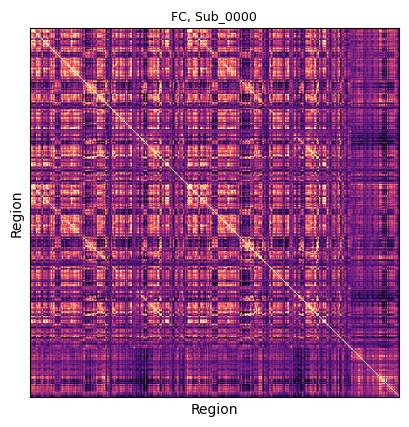

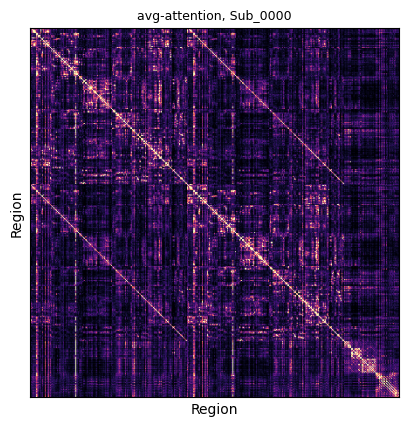

In [36]:
import matplotlib.pyplot as plt
def show_matrix(ax, matrix, title):
    v_lo, v_hi = np.percentile(matrix, 1), np.percentile(matrix, 99)
    im = ax.imshow(matrix, cmap="magma", vmin=v_lo, vmax=v_hi)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("Region")
    ax.set_ylabel("Region")
    ax.set_title(f"{title}, Sub_0000", fontsize=9)
    return im

fig, ax = plt.subplots(1,1)
show_matrix(ax, fcs[0] / np.max(fcs[0]), "FC")
plt.savefig("./figures/Sub_0000_FC_thresholded.png")
plt.show()

fig, ax = plt.subplots(1,1)
show_matrix(ax, attns[0] / np.max(attns[0]), "avg-attention")
plt.savefig("./figures/Sub_0000_attn_thresholded.png")
plt.show()

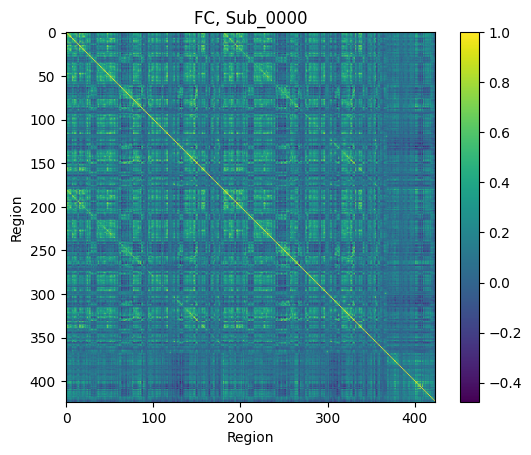

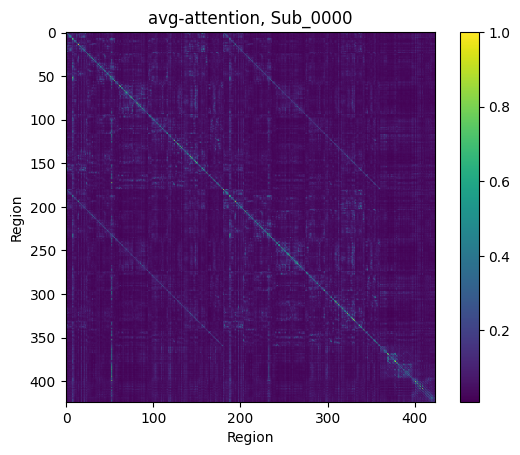

In [29]:
import matplotlib.pyplot as plt

im = plt.imshow(fcs[0] / np.max(fcs[0]))
plt.xlabel("Region")
plt.ylabel("Region")
plt.title("FC, Sub_0000")
plt.colorbar(im)
plt.savefig("./figures/Sub_0000_FC.png")
plt.show()

im = plt.imshow(attns[0] / np.max(attns[0]))
plt.xlabel("Region")
plt.ylabel("Region")
plt.title("avg-attention, Sub_0000")
plt.colorbar(im)
plt.savefig("./figures/Sub_0000_attn.png")
plt.show()

In [8]:
csv_path = os.path.join(OUTPUTS_DIR, "fc_attention_correlation.csv")
with open(csv_path, "w", newline="") as f_out:
    writer = csv.DictWriter(f_out, fieldnames=["subject_id", "r_fc_attention"])
    writer.writeheader()
    writer.writerows(results)
print(f"Saved per-subject correlations -> {csv_path}")

Saved per-subject correlations -> outputs/fc_attention_correlation.csv


## Distribution across subjects

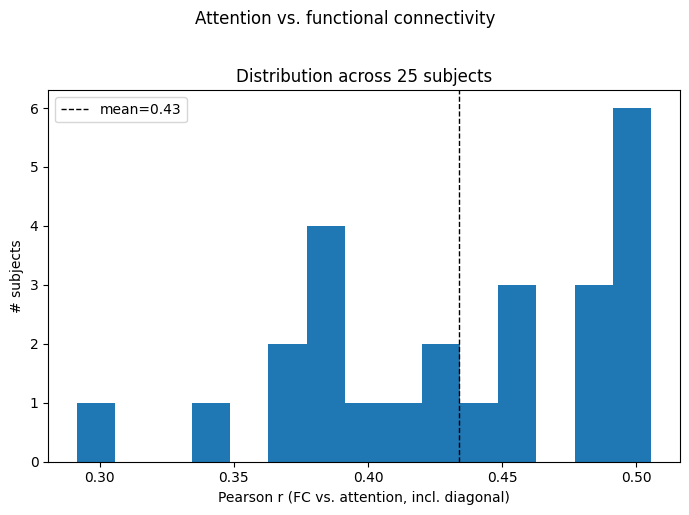

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.hist(r_values, bins=15, color="tab:blue")
ax.axvline(r_values.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={r_values.mean():.2f}")
ax.set_xlabel("Pearson r (FC vs. attention, incl. diagonal)")
ax.set_ylabel("# subjects")
ax.set_title(f"Distribution across {len(results)} subjects")
ax.legend()

fig.suptitle("Attention vs. functional connectivity", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "fc_attention_correlation_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()

## Windowed FC vs. per-patch attention (fair, time-resolved comparison)

The comparison above has an apples-to-oranges issue: it correlates the attention matrix
*averaged over* the 10 within-window, 20-TR time patches (`attn_reshaped.mean(dim=(1, 3))`,
as saved by `run_model.py`) against an FC computed on the *entire* recording (1200 TRs) --
not on the same time support the attention was actually computed over.

A fairer comparison keeps the attention matrix's own time resolution. At a token
resolution of `timepoint_patching_size=20` TRs, one `window_size=200`-TR window contains
`num_patches=10` time patches, so the model's `[4240, 4240]` last-layer attention (before
averaging over time patches) decomposes into a `[num_regions, num_patches, num_regions,
num_patches]` tensor. Its 10 diagonal blocks `attn_reshaped[:, t, :, t]` (t=0..9) are each a
same-time, region x region `424 x 424` attention matrix -- one per 20-TR patch. We correlate
each against the FC computed **only on that patch's own 20 TRs** of the raw time series,
giving 10 `(patch, r)` pairs per subject instead of 1, i.e. a within-subject distribution of
10 values, and a 250-value (25 subjects x 10 patches) distribution across all subjects.

This needs a fresh forward pass per subject: `run_model.py` only ever persists the
patch-*averaged* `_attention.npy` and the lag-averaged `_ftau{lag}.npy` -- the per-patch
diagonal blocks used here were never saved to disk. We reuse the exact
loading/preprocessing/guard code from `run_model.py` (same checkpoint, same identity-noise
token-order guard), but with a single `window_size=200` window starting at TR 0 (not the 3
sliding, overlapping windows `run_model.py` averages over), so that patch `t` maps
unambiguously to raw TRs `[20t, 20(t+1))` -- averaging over overlapping sliding windows would
mix different absolute TR ranges into "the same" patch index.

In [45]:
import sys

sys.path.insert(0, os.path.abspath(".."))

import torch

from run_model import load_brainlm_model, load_spatial_coordinates

# run_model imports visualize_attention, which calls matplotlib.use("Agg") for headless
# script runs -- re-enable the inline backend for this notebook (see attention_by_window.ipynb).
get_ipython().run_line_magic("matplotlib", "inline")

COORDS = "../data/input/toolkit/atlases/A424_Coordinates.dat"
HF_REPO = "vandijklab/brainlm"
SUBFOLDER = "old_13M"
WINDOW_SIZE = 200  # TRs; single window starting at TR 0 (see markdown above)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model, config = load_brainlm_model(HF_REPO, SUBFOLDER)
model.to(device)

spatial_coords_base = load_spatial_coordinates(COORDS).to(device)

num_regions = config.num_brain_voxels
timepoint_patching_size = config.timepoint_patching_size
num_patches = WINDOW_SIZE // timepoint_patching_size
seq_len = num_regions * num_patches
# Identity noise -> ids_restore stays the identity permutation (see run_model.py docstring).
identity_noise = (torch.arange(seq_len, dtype=torch.float32) / seq_len).unsqueeze(0).to(device)

print(f"num_regions={num_regions}, num_patches={num_patches} (patch={timepoint_patching_size} TRs), seq_len={seq_len}")

Device: cpu


loading configuration file config.json from cache at /home/fmoss/.cache/huggingface/hub/models--vandijklab--brainlm/snapshots/4c54e0cccf920d9d6af7c647cb866fc19c60cf26/old_13M/config.json
Model config BrainLMConfig {
  "_name_or_path": "/home/ahf38/palmer_scratch/brainlm/training-runs/2023-07-17-19_00_00/checkpoint-1750",
  "architectures": [
    "BrainLMForPretraining"
  ],
  "attention_probs_dropout_prob": 0.1,
  "conv_kernel_size": 65,
  "decoder_hidden_size": 512,
  "decoder_intermediate_size": 1024,
  "decoder_num_attention_heads": 4,
  "decoder_num_hidden_layers": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 512,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 1024,
  "inv_coeff_init_option": false,
  "layer_norm_eps": 1e-12,
  "loss_fn": "mse",
  "mask_ratio": 0.2,
  "max_eval_samples": 800,
  "model_type": "brainlm_mae",
  "norm_pix_loss": false,
  "num_attention_heads": 4,
  "num_brain_voxels": 424,
  "num_channels": 3,
  "n

num_regions=424, num_patches=10 (patch=20 TRs), seq_len=4240


In [52]:
def robust_scale_regions(window_raw):
    """Per-region median/IQR scaling, same recipe as run_model.py's preprocess_subject_data,
    applied to a single [window_size, num_regions] window. Only affects the model's input --
    FC below uses the raw window directly (Pearson r is invariant to this per-region affine
    transform anyway, per the design note at the top of this notebook)."""
    scaled = window_raw.T.copy()  # [num_regions, window_size]
    for r in range(scaled.shape[0]):
        v = scaled[r, :]
        median = np.median(v)
        q75, q25 = np.percentile(v, [75, 25])
        iqr = q75 - q25
        if iqr == 0:
            iqr = 1e-6
        scaled[r, :] = (v - median) / iqr
    return scaled


def per_patch_attention(window_raw):
    """Single window_size=200-TR window -> [num_regions, num_patches, num_regions, num_patches]
    last-layer attention (heads averaged, CLS dropped, time patches kept separate)."""
    scaled = robust_scale_regions(window_raw)
    fmri_window = torch.tensor(scaled[None, ...], dtype=torch.float32).to(device)

    with torch.no_grad():
        outputs = model.vit(
            signal_vectors=fmri_window,
            xyz_vectors=spatial_coords_base,
            noise=identity_noise,
            output_attentions=True,
        )

    ids_restore = outputs.ids_restore.cpu().numpy()
    if not np.array_equal(ids_restore, np.broadcast_to(np.arange(seq_len), ids_restore.shape)):
        raise RuntimeError("Token order was shuffled (ids_restore != identity); refusing to reshape.")

    attn_no_cls = outputs.attentions[-1].mean(dim=(0, 1))[1:, 1:]  # heads averaged -> [seq_len, seq_len]
    return attn_no_cls.view(num_regions, num_patches, num_regions, num_patches).cpu().numpy()


windowed_results = []
attns_single_window = []  # per-subject [424, 424], time-patch-averaged but from the first window ONLY
all_patch_rs = []  # per-subject list of num_patches r values, same order as subject_ids_with_attention
with h5py.File(INPUT_H5, "r") as f:
    for sub_id in subject_ids_with_attention:
        raw_ts = f["parcel_ts"][h5_index_of[sub_id], :, :]  # [num_timepoints, num_regions]
        window_raw = raw_ts[:WINDOW_SIZE, :]  # TRs [0, 200) -> patch t <-> TRs [20t, 20(t+1))
        if np.isnan(window_raw).any():
            raise ValueError(f"{sub_id}: NaNs in the first {WINDOW_SIZE} TRs; cannot align patches to fixed TR ranges.")

        attn_reshaped = per_patch_attention(window_raw)
        attns_single_window.append(attn_reshaped.mean(axis=(1, 3)))

        patch_rs = []
        for t in range(num_patches):
            attn_block = attn_reshaped[:, t, :, t]  # 424x424, same-time region x region attention
            tr_lo, tr_hi = t * timepoint_patching_size, (t + 1) * timepoint_patching_size
            fc_block = compute_fc(window_raw[tr_lo:tr_hi, :])
            r = np.corrcoef(fc_block.ravel(), attn_block.ravel())[0, 1]
            patch_rs.append(r)
            windowed_results.append(
                {"subject_id": sub_id, "patch": t, "tr_start": tr_lo, "tr_end": tr_hi, "r_fc_attention": r}
            )

        all_patch_rs.append(patch_rs)
        print(f"{sub_id}: per-patch r mean={np.mean(patch_rs):.4f}, std={np.std(patch_rs):.4f}")

windowed_r_values = np.array([res["r_fc_attention"] for res in windowed_results])
print(
    f"\n{len(subject_ids_with_attention)} subjects x {num_patches} patches = {len(windowed_results)} comparisons -- "
    f"r(FC, attention): mean={windowed_r_values.mean():.4f}, median={np.median(windowed_r_values):.4f}, "
    f"std={windowed_r_values.std():.4f}, min={windowed_r_values.min():.4f}, max={windowed_r_values.max():.4f}"
)

Sub_0000: per-patch r mean=0.1201, std=0.0231
Sub_0001: per-patch r mean=0.1220, std=0.0291
Sub_0002: per-patch r mean=0.1582, std=0.0474
Sub_0004: per-patch r mean=0.0913, std=0.0377
Sub_0005: per-patch r mean=0.1487, std=0.0497
Sub_0006: per-patch r mean=0.1145, std=0.0405
Sub_0007: per-patch r mean=0.1262, std=0.0314
Sub_0008: per-patch r mean=0.1051, std=0.0326
Sub_0009: per-patch r mean=0.1202, std=0.0369
Sub_0010: per-patch r mean=0.1605, std=0.0231
Sub_0011: per-patch r mean=0.1485, std=0.0382
Sub_0012: per-patch r mean=0.1044, std=0.0151
Sub_0013: per-patch r mean=0.0825, std=0.0351
Sub_0014: per-patch r mean=0.1330, std=0.0268
Sub_0015: per-patch r mean=0.1234, std=0.0340
Sub_0016: per-patch r mean=0.1500, std=0.0225
Sub_0017: per-patch r mean=0.1179, std=0.0438
Sub_0018: per-patch r mean=0.1126, std=0.0321
Sub_0019: per-patch r mean=0.1085, std=0.0308
Sub_0020: per-patch r mean=0.1468, std=0.0544
Sub_0021: per-patch r mean=0.1311, std=0.0293
Sub_0022: per-patch r mean=0.1172,

### Quick look at the per-patch correlations

Three views of the same 25-subjects x 10-patches `r` values computed above, before the more
polished versions later in the notebook:

1. A `subjects x patches` matrix of `r` itself -- do some patches (time windows within the
   200-TR window) systematically track FC better than others, across subjects?
2. The per-patch distribution (10 values) for two example subjects -- how much does `r` vary
   *within* a single subject, across time?
3. All 250 values pooled into one distribution, subject and patch identity dropped -- the
   overall spread of "how well does one time-patch's attention match that time-patch's FC?"

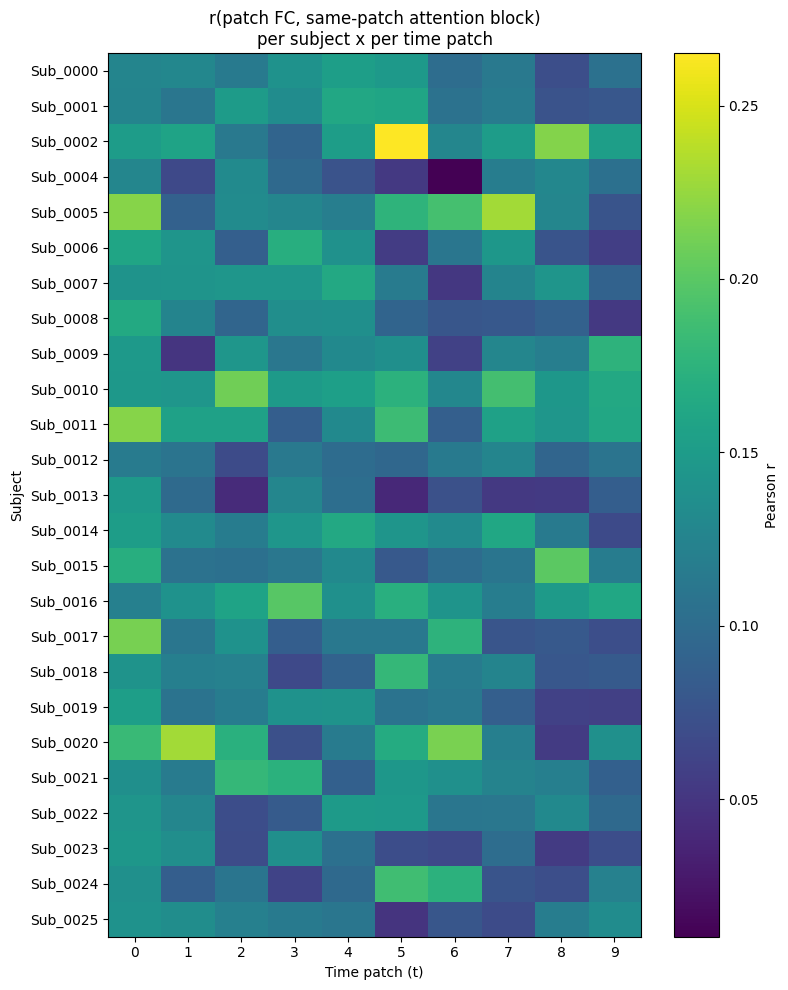

In [53]:
r_matrix = np.array(all_patch_rs)  # [n_subjects, num_patches]

fig, ax = plt.subplots(1, 1, figsize=(8, 10))
im = ax.imshow(r_matrix, aspect="auto", cmap="viridis")
ax.set_xlabel("Time patch (t)")
ax.set_ylabel("Subject")
ax.set_xticks(range(num_patches))
ax.set_yticks(range(len(subject_ids_with_attention)))
ax.set_yticklabels(subject_ids_with_attention)
ax.set_title("r(patch FC, same-patch attention block)\nper subject x per time patch")
plt.colorbar(im, ax=ax, label="Pearson r")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "windowed_fc_attention_subject_patch_matrix.png"), dpi=130, bbox_inches="tight")
plt.show()

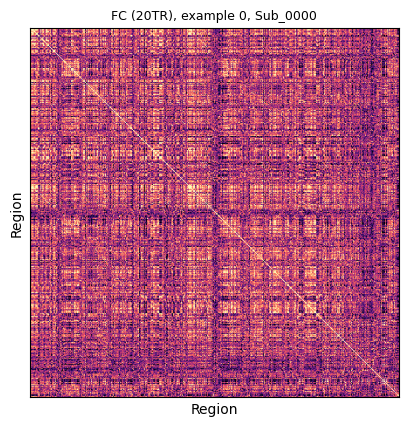

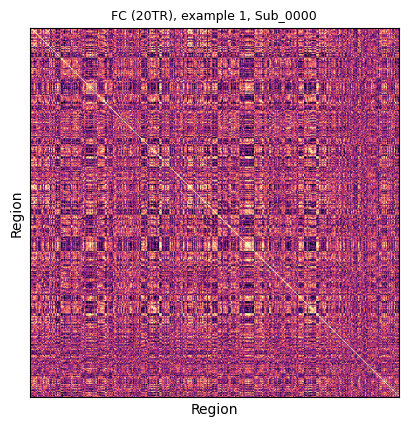

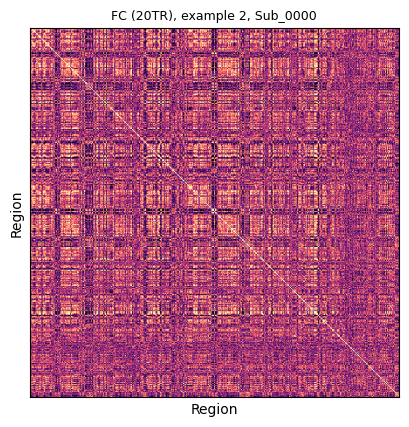

In [68]:
for i in range(3):
    time_step = i*20
    fc_small = compute_fc(raw_ts=raw_ts[time_step:time_step+20])
    fig, ax = plt.subplots(1,1)
    show_matrix(ax, fc_small, f"FC (20TR), example {i}")
    plt.savefig(f"./figures/fc_20tr_{i}.png")
    plt.show()


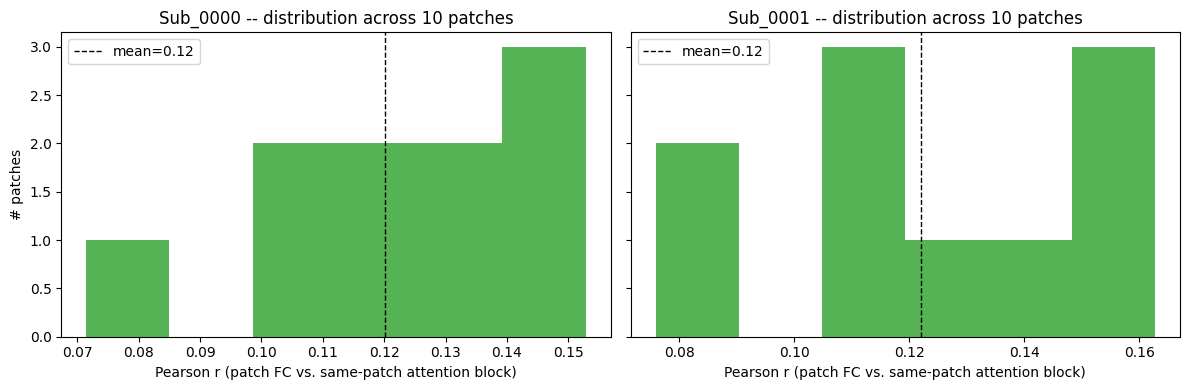

In [54]:
EXAMPLE_SUBJECTS = subject_ids_with_attention[:2]

fig, axes = plt.subplots(1, len(EXAMPLE_SUBJECTS), figsize=(6 * len(EXAMPLE_SUBJECTS), 4), sharey=True)
for ax, sub_id in zip(axes, EXAMPLE_SUBJECTS):
    idx = subject_ids_with_attention.index(sub_id)
    rs = r_matrix[idx]
    ax.hist(rs, bins=6, color="tab:green", alpha=0.8)
    ax.axvline(rs.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={rs.mean():.2f}")
    ax.set_xlabel("Pearson r (patch FC vs. same-patch attention block)")
    ax.set_title(f"{sub_id} -- distribution across {num_patches} patches")
    ax.legend()
axes[0].set_ylabel("# patches")

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "windowed_fc_attention_two_subjects_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()

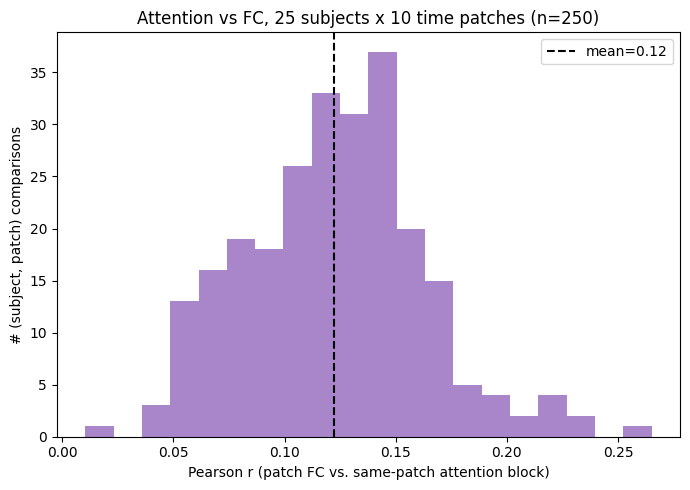

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.hist(windowed_r_values, bins=20, color="tab:purple", alpha=0.8)
ax.axvline(windowed_r_values.mean(), color="black", linestyle="--", linewidth=1.5,
           label=f"mean={windowed_r_values.mean():.2f}")
ax.set_xlabel("Pearson r (patch FC vs. same-patch attention block)")
ax.set_ylabel("# (subject, patch) comparisons")
ax.set_title(f"Attention vs FC, 25 subjects x 10 time patches (n={len(windowed_r_values)})")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "windowed_fc_attention_aggregated_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()

In [47]:
windowed_csv_path = os.path.join(OUTPUTS_DIR, "windowed_fc_attention_correlation.csv")
with open(windowed_csv_path, "w", newline="") as f_out:
    writer = csv.DictWriter(f_out, fieldnames=["subject_id", "patch", "tr_start", "tr_end", "r_fc_attention"])
    writer.writeheader()
    writer.writerows(windowed_results)
print(f"Saved per-subject, per-patch correlations -> {windowed_csv_path}")

Saved per-subject, per-patch correlations -> outputs/windowed_fc_attention_correlation.csv


## Revisiting the whole-series comparison: single window vs. 3-window average

The very first comparison in this notebook used the disk-saved `_attention.npy`, which
`run_model.py` builds by averaging over **3** sliding, overlapping windows (`[0,200)`,
`[500,700)`, `[1000,1200)` for a 1200-TR recording) as well as heads and time patches. That
3-window average is a second, separate source of temporal mismatch against the whole-series
FC, on top of the time-patch averaging the windowed analysis above already addresses.

`attns_single_window` (collected in the loop above, as `attn_reshaped.mean(axis=(1, 3))` --
i.e. still averaged over the 10 time patches, but computed from **only the first window**,
TRs `[0, 200)`, with no cross-window averaging at all) lets us isolate the effect of that
3-window averaging on its own: same FC (still the full 1200-TR series, unchanged from the
first comparison), same "time-averaged region x region attention" quantity, but sourced from
one window instead of three.

In [48]:
r_single_window_values = np.array([
    np.corrcoef(fc.ravel(), attn_single.ravel())[0, 1]
    for fc, attn_single in zip(fcs, attns_single_window)
])

for sub_id, r in zip(subject_ids_with_attention, r_single_window_values):
    print(f"{sub_id}: r(whole-series FC, single-window time-avg attention) = {r:.4f}")

print(
    f"\n{len(subject_ids_with_attention)} subjects -- r(FC, single first-window attention): "
    f"mean={r_single_window_values.mean():.4f}, median={np.median(r_single_window_values):.4f}, "
    f"std={r_single_window_values.std():.4f}, min={r_single_window_values.min():.4f}, "
    f"max={r_single_window_values.max():.4f}"
)
print(f"(disk-based, 3-window-averaged attention gave mean={r_values.mean():.4f}, for comparison)")

Sub_0000: r(whole-series FC, single-window time-avg attention) = 0.4439
Sub_0001: r(whole-series FC, single-window time-avg attention) = 0.4998
Sub_0002: r(whole-series FC, single-window time-avg attention) = 0.2812
Sub_0004: r(whole-series FC, single-window time-avg attention) = 0.4861
Sub_0005: r(whole-series FC, single-window time-avg attention) = 0.3822
Sub_0006: r(whole-series FC, single-window time-avg attention) = 0.4362
Sub_0007: r(whole-series FC, single-window time-avg attention) = 0.5003
Sub_0008: r(whole-series FC, single-window time-avg attention) = 0.3985
Sub_0009: r(whole-series FC, single-window time-avg attention) = 0.3798
Sub_0010: r(whole-series FC, single-window time-avg attention) = 0.4049
Sub_0011: r(whole-series FC, single-window time-avg attention) = 0.3292
Sub_0012: r(whole-series FC, single-window time-avg attention) = 0.3722
Sub_0013: r(whole-series FC, single-window time-avg attention) = 0.4727
Sub_0014: r(whole-series FC, single-window time-avg attention) =

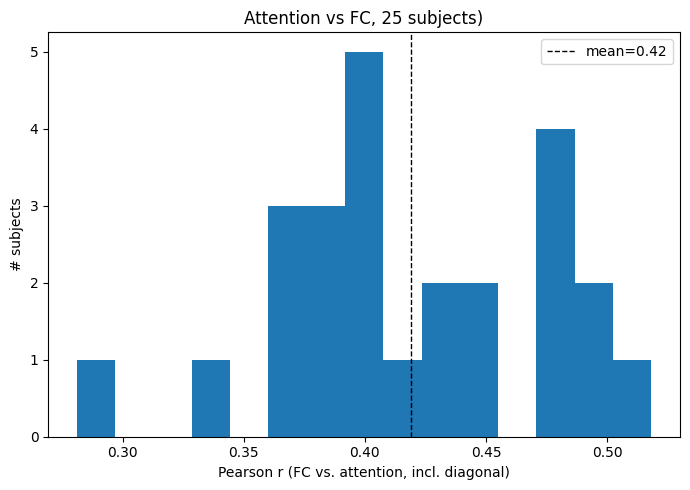

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.hist(r_single_window_values, bins=15, color="tab:blue")
ax.axvline(r_single_window_values.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={r_single_window_values.mean():.2f}")
ax.set_xlabel("Pearson r (FC vs. attention, incl. diagonal)")
ax.set_ylabel("# subjects")
ax.set_title(f"Attention vs FC, 25 subjects)")
ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "fc_attention_correlation_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()

## Distributions: per-subject (10 patches) and across all subjects

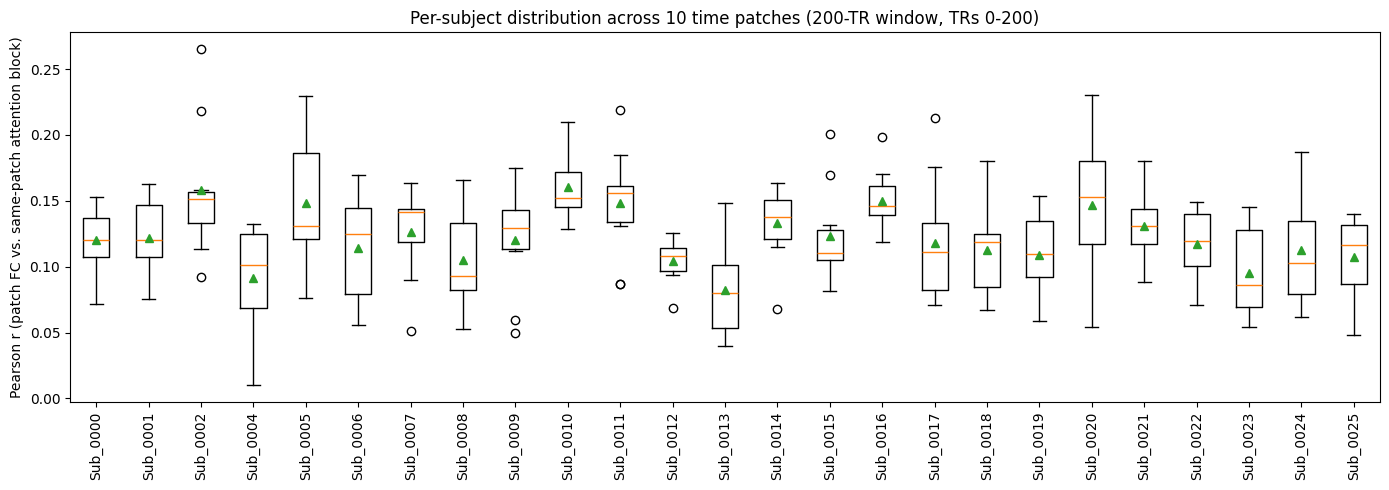

In [13]:
per_subject_rs = [
    [res["r_fc_attention"] for res in windowed_results if res["subject_id"] == sub_id]
    for sub_id in subject_ids_with_attention
]

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.boxplot(per_subject_rs, showmeans=True)
ax.set_xticks(range(1, len(subject_ids_with_attention) + 1))
ax.set_xticklabels(subject_ids_with_attention, rotation=90)
ax.set_ylabel("Pearson r (patch FC vs. same-patch attention block)")
ax.set_title(f"Per-subject distribution across {num_patches} time patches ({WINDOW_SIZE}-TR window, TRs 0-{WINDOW_SIZE})")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "windowed_fc_attention_per_subject_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()

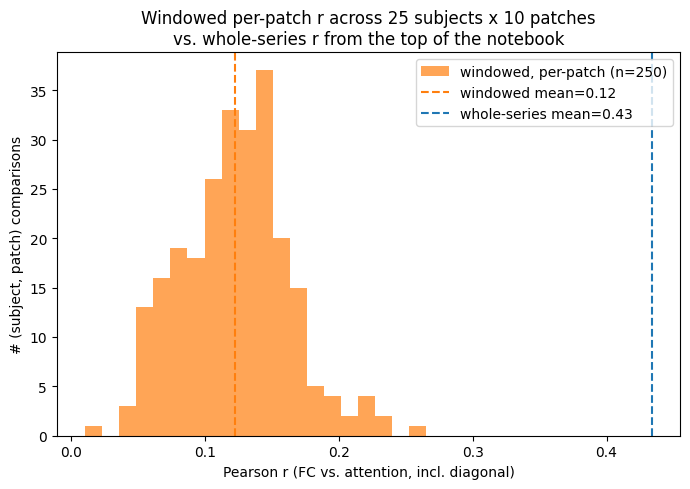

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.hist(windowed_r_values, bins=20, color="tab:orange", alpha=0.7, label=f"windowed, per-patch (n={len(windowed_r_values)})")
ax.axvline(windowed_r_values.mean(), color="tab:orange", linestyle="--", linewidth=1.5,
           label=f"windowed mean={windowed_r_values.mean():.2f}")
ax.axvline(r_values.mean(), color="tab:blue", linestyle="--", linewidth=1.5,
           label=f"whole-series mean={r_values.mean():.2f}")
ax.set_xlabel("Pearson r (FC vs. attention, incl. diagonal)")
ax.set_ylabel("# (subject, patch) comparisons")
ax.set_title(
    f"Windowed per-patch r across {len(subject_ids_with_attention)} subjects x {num_patches} patches\n"
    "vs. whole-series r from the top of the notebook"
)
ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "windowed_fc_attention_correlation_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()